# Training Based Model
TWO-STAGE CHEATING DETECTION SYSTEM:

Stage 1 – YOLO (Person Detection)

    Input: Whole class video

    Output: Cropped student videos

Stage 2 – ResNet18 (Action Classification)

    Input: Single-student cropped videos

    Output: 5 classes

# R3D-18 = 3D CNN (frames × height × width)
**ResNet18:**	 Single image (❌ bad for cheating)

**R3D-18:**	Motion + posture over time

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!pip install torch torchvision opencv-python scikit-learn matplotlib

In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision.models.video import r3d_18
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
VIDEO_DIR = "/kaggle/input/datasets/rimmajeed/cropped_videos"
LABELS_CSV = "/kaggle/input/datasets/rimmajeed/labels/labels.csv"

In [ ]:
# Load Labels
df = pd.read_csv(LABELS_CSV)
df.head(6)


In [ ]:
# Define Classes
class_names = [
    "cheating_copying",
    "cheating_gesture",
    "cheating_mobile_use",
    "cheating_notes",
    "normal"
]

class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}


In [ ]:
print(class_to_idx)

In [ ]:
# Step 6: Laod R3D-18 (but backbone is freezed, only last layer train, as 193 videos now)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = r3d_18(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = torch.nn.Linear(model.fc.in_features, 5)

model = model.to(device)


In [ ]:
# # Step 6: Load R3D-18   (use when data is more than 400 video)
# device = "cuda" if torch.cuda.is_available() else "cpu"

# model = r3d_18(pretrained=True)
# model.fc = torch.nn.Linear(model.fc.in_features, 5)

# model = model.to(device)

In [ ]:
# Step 7: Video Transform (3D CNN Form)
video_transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.Normalize(
        mean=[0.43216, 0.394666, 0.37645],
        std=[0.22803, 0.22145, 0.216989]
    )
])

In [ ]:
# Step 8: Load video clip (even when video is small than 16 frames repeat last one again)
def load_video_clip(video_path, num_frames=16):
    cap = cv2.VideoCapture(video_path)

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (112, 112))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return None

    # If video has fewer frames than required → PAD
    if len(frames) < num_frames:
        while len(frames) < num_frames:
            frames.append(frames[-1])  # repeat last frame

    # If more frames → uniformly sample
    indices = np.linspace(0, len(frames)-1, num_frames).astype(int)
    frames = [frames[i] for i in indices]

    clip = np.array(frames).astype(np.float32) / 255.0
    clip = np.transpose(clip, (3, 0, 1, 2))  # C,T,H,W
    clip = torch.tensor(clip)

    return clip

In [ ]:
# # Step 9: Training setup( Balanced loss)

# # I - Weights formula

# # Map labels to integers safely
# labels_idx = df["label"].map(class_to_idx)

# #  Check for missing labels
# if labels_idx.isna().any():
#     print("Warning: Some labels are invalid/missing:")
#     print(df.loc[labels_idx.isna()])
#     # Drop rows with invalid labels
#     df = df[~labels_idx.isna()].reset_index(drop=True)
#     labels_idx = df["label"].map(class_to_idx)

# # Convert to integers
# labels_idx = labels_idx.astype(int)

# # Compute class weights (balanced)
# counts = np.bincount(labels_idx)
# weights = counts.max() / counts.astype(float)
# class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

# # Loss & optimizer
# criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# print("Class weights:", weights)


In [ ]:
# Step: 9-  II- Weight formula update (Note: use only I above or this one)

from sklearn.utils.class_weight import compute_class_weight

# Map labels to integers safely
labels_idx = df["label"].map(class_to_idx)

#  Check for missing labels
if labels_idx.isna().any():
    print("Warning: Some labels are invalid/missing:")
    print(df.loc[labels_idx.isna()])
    # Drop rows with invalid labels
    df = df[~labels_idx.isna()].reset_index(drop=True)
    labels_idx = df["label"].map(class_to_idx)

# Convert to integers
labels_idx = labels_idx.astype(int)

classes = np.unique(labels_idx)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels_idx
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
print("Class weights:", class_weights)

In [ ]:
# # Without weight
# optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
# criterion = torch.nn.CrossEntropyLoss()

In [ ]:
from torch.utils.data import Dataset, DataLoader

class VideoDataset(Dataset):
    def __init__(self, df, video_dir):
        self.df = df
        self.video_dir = video_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video_path = os.path.join(self.video_dir, row["video"])
        label = class_to_idx[row["label"]]

        clip = load_video_clip(video_path)

        if clip is None:
            # If video failed, return zeros to avoid crash
            clip = torch.zeros(3,16,112,112)

        return clip, label

BATCH_SIZE = 4

dataset = VideoDataset(df, VIDEO_DIR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# step 10: Train R3D-18 (but with batch size 4, asa data set is small)
EPOCHS = 50
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    total = 0

    for clips, labels in loader:

        clips = clips.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(clips)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1} | Loss: {total_loss:.3f} | Accuracy: {acc:.3f}")

In [ ]:
# Step 11: Save model correctly in Kaggle

import torch
import os

save_path = "/kaggle/working/r3d18_cheating_194_v2_batch-4.pth"

torch.save(model.state_dict(), save_path)

print("Model saved at:", save_path)
print("Files in working folder:", os.listdir("/kaggle/working"))


In [ ]:
# clickable download link
from IPython.display import FileLink
FileLink("/kaggle/working/r3d18_cheating_194_v2_batch-4.pth")

In [ ]:
# Step 12: Video Prediction
def predict_video(video_path):
    model.eval()
    clip = load_video_clip(video_path)

    if clip is None:
        return "Invalid", 0.0

    clip = clip.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(clip)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]

    pred = np.argmax(probs)
    return idx_to_class[pred], probs[pred]


In [ ]:
# Model Evaluation
model.eval()
y_true, y_pred = [], []

for _, row in df.iterrows():
    video_path = os.path.join(VIDEO_DIR, row["video"])
    pred, _ = predict_video(video_path)

    # Skip videos that could not be processed (returned 'Invalid')
    if pred == "Invalid":
        print(f"Skipping video {row['video']} due to invalid prediction (e.g., not enough frames).")
        continue

    y_true.append(class_to_idx[row["label"]])
    y_pred.append(class_to_idx[pred])

if y_true:
    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=35)
    plt.show()
else:
    print("No valid predictions were made to calculate accuracy.")

In [ ]:
# Test on my videos
from google.colab import files

# print("Upload custom student video:")
# uploaded = files.upload()

# video = list(uploaded.keys())[0]

# 1- Gesture
print("\nOrignal video: Gesture")
video = "/content/drive/MyDrive/ourDataset/dataset_f3/s6.mp4"
pred, conf = predict_video(video)

print("Predicted:", pred)
print("Confidence:", round(float(conf),2))


# 2- Mobile + Coping
print("\nOrignal video: Mobile use + copying")
video = "/content/drive/MyDrive/ourDataset/dataset_f3/s8.mp4"
pred, conf = predict_video(video)

print("Predicted:", pred)
print("Confidence:", round(float(conf),2))

# 2- Coping
print("\nOrignal video:copying")
video = "/content/drive/MyDrive/ourDataset/dataset_f3/c3.mp4"
pred, conf = predict_video(video)

print("Predicted:", pred)
print("Confidence:", round(float(conf),2))

# 3- Notes
print("\nOrignal video: cheating_notes")
video = "/content/drive/MyDrive/ourDataset/dataset_f3/n4.mp4"
pred, conf = predict_video(video)

print("Predicted:", pred)
print("Confidence:", round(float(conf),2))


# 4- Mobile
print("\nOrignal video: Mobile_use")
video = "/content/drive/MyDrive/ourDataset/dataset_f3/m4.mp4"
pred, conf = predict_video(video)

print("Predicted:", pred)
print("Confidence:", round(float(conf),2))


# 5- Gesture
print("\nOrignal video: Gesture")
video = "/content/drive/MyDrive/ourDataset/dataset_f3/g2.mp4"
pred, conf = predict_video(video)

print("Predicted:", pred)
print("Confidence:", round(float(conf),2))

In [ ]:
# Test on my videos
from google.colab import files

print("Upload custom student video:")
uploaded = files.upload()

video = list(uploaded.keys())[0]
# video = "/content/s6.mp4"
pred, conf = predict_video(video)

print("Predicted:", pred)
print("Confidence:", round(float(conf),2))


# Testing on whole class video

In [ ]:
!pip install ultralytics opencv-python torch torchvision

In [ ]:
import cv2
import os
import torch
import numpy as np
from ultralytics import YOLO
from torchvision.models.video import r3d_18


In [ ]:
# Load Models
device = "cuda" if torch.cuda.is_available() else "cpu"

# YOLO for student detection + tracking
yolo = YOLO("yolov8n.pt")

# R3D‑18 for cheating classification
model = r3d_18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load("/content/drive/MyDrive/My_Models/r3d18_cheating_1_batch-4.pth"))
model = model.to(device)
model.eval()


In [ ]:
# classes
class_names = [
    "cheating_copying",
    "cheating_gesture",
    "cheating_mobile_use",
    "cheating_notes",
    "normal"
]


In [ ]:
# step no 4: Frame --> Clip Function (critcal part)
def make_clip(frames):
    clip = []
    for f in frames:
        f = cv2.resize(f, (112,112))
        f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        f = torch.from_numpy(f).permute(2,0,1).float() / 255.0
        clip.append(f)

    clip = torch.stack(clip)           # [T,C,H,W]
    clip = clip.permute(1,0,2,3)        # [C,T,H,W]
    return clip.unsqueeze(0).to(device)


In [ ]:
# step 5: Predict clip
def predict_clip(clip):
    with torch.no_grad():
        out = model(clip)
        prob = torch.softmax(out, dim=1)[0]
        cls = torch.argmax(prob).item()
    return class_names[cls], float(prob[cls])


In [ ]:
# Step 6: Whole class video
def analyze_class_video(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)

    student_buffers = {}   # student_id → frames
    logs = {}              # student_id → events

    frame_no = 0
    CLIP_LEN = 16

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = yolo.track(frame, persist=True, classes=[0], conf=0.4)

        if results[0].boxes.id is None:
            continue

        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)

        for box, sid in zip(boxes, ids):
            x1,y1,x2,y2 = map(int, box)
            crop = frame[y1:y2, x1:x2]

            if sid not in student_buffers:
                student_buffers[sid] = []
                logs[sid] = []

            student_buffers[sid].append(crop)

            if len(student_buffers[sid]) == CLIP_LEN:
                clip = make_clip(student_buffers[sid])
                label, conf = predict_clip(clip)

                start_t = frame_no / fps
                end_t = (frame_no + CLIP_LEN) / fps

                logs[sid].append({
                    "start": round(start_t,2),
                    "end": round(end_t,2),
                    "label": label,
                    "confidence": round(conf,2)
                })

                student_buffers[sid].pop(0)

        frame_no += 1

    cap.release()
    return logs


In [ ]:
# Upload whole class video
from google.colab import files

# print("Upload WHOLE CLASS video:")
# uploaded = files.upload()

# video_name = list(uploaded.keys())[0]

video_name = "/content/drive/MyDrive/ourDataset/dataset_f2/crop40s.mp4"
# logs = analyze_class_video(video_name)


In [ ]:
logs = analyze_class_video(video_name)

print("Logs keys:", logs.keys())
print("Total students detected:", len(logs))

total_events = sum(len(v) for v in logs.values())
print("Total events detected:", total_events)

In [ ]:
# log too long so log save in chunks form
import pandas as pd
def analyze_class_video(video_path, save_csv_path, chunk_save_interval=200):

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)

    student_buffers = {}
    frame_no = 0
    CLIP_LEN = 16

    # Create CSV file with header first
    if not os.path.exists(save_csv_path):
        pd.DataFrame(columns=[
            "student_id",
            "start_time_s",
            "end_time_s",
            "cheating_type",
            "confidence"
        ]).to_csv(save_csv_path, index=False)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = yolo.track(frame, persist=True, classes=[0], conf=0.4, verbose=False)

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            ids = results[0].boxes.id.cpu().numpy().astype(int)

            for box, sid in zip(boxes, ids):
                x1,y1,x2,y2 = map(int, box)
                crop = frame[y1:y2, x1:x2]

                if sid not in student_buffers:
                    student_buffers[sid] = []

                student_buffers[sid].append(crop)

                if len(student_buffers[sid]) == CLIP_LEN:
                    clip = make_clip(student_buffers[sid])
                    label, conf = predict_clip(clip)

                    start_t = frame_no / fps
                    end_t = (frame_no + CLIP_LEN) / fps

                    row = {
                        "student_id": sid,
                        "start_time_s": round(start_t,2),
                        "end_time_s": round(end_t,2),
                        "cheating_type": label,
                        "confidence": round(conf,2)
                    }

                    # 🔥 Append immediately to CSV
                    pd.DataFrame([row]).to_csv(
                        save_csv_path,
                        mode='a',
                        header=False,
                        index=False
                    )

                    student_buffers[sid].pop(0)

        # 🔥 Save progress info every N frames
        if frame_no % chunk_save_interval == 0:
            print(f"Processed frame: {frame_no}")

        frame_no += 1

    cap.release()
    print("✅ Finished processing.")

In [ ]:
# chunk file run
csv_path = "/content/drive/MyDrive/My_Models/video_2_log_chunk.csv"
analyze_class_video(video_name, csv_path)

In [ ]:
# Step 8: Final output cheating Save log in csv
import pandas as pd

# Prepare data for CSV
rows = []
for student_id, events in logs.items():
    for e in events:
        rows.append({
            "student_id": student_id,
            "start_time_s": e['start'],
            "end_time_s": e['end'],
            "cheating_type": e['label'],
            "confidence": e['confidence']
        })

# Create DataFrame
log_df = pd.DataFrame(rows)

# Save to CSV
csv_path = "/content/drive/MyDrive/Results/video_2_log_chunk.csv"
log_df.to_csv(csv_path, index=False)
print(f"Cheating log saved to {csv_path}")

# Optional: Display in notebook
print("\n===== Cheating Log =====")
print(log_df)


In [ ]:
# Preview Video
from IPython.display import HTML
from base64 import b64encode
import cv2

# Path to save annotated video
annotated_video_path = "/content/drive/MyDrive/Results/annotated_class_video_2.mp4"

cap = cv2.VideoCapture(video_name)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(annotated_video_path, fourcc, fps, (width, height))

frame_no = 0
student_buffers = {}
CLIP_LEN = 16

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = yolo.track(frame, persist=True, classes=[0], conf=0.4)

    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)

        for box, sid in zip(boxes, ids):
            x1,y1,x2,y2 = map(int, box)
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            # Find predictions for this frame
            student_events = [e for e in logs.get(sid, []) if e['start'] <= frame_no/fps <= e['end']]
            if student_events:
                label = student_events[-1]['label']
                conf = student_events[-1]['confidence']
                text = f"Student {sid}: {label} ({conf})"
                cv2.putText(frame, text, (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

    out.write(frame)
    frame_no += 1

cap.release()
out.release()

# Display in notebook
mp4 = open(annotated_video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f"""
<video width=800 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")


In [ ]:
from IPython.display import FileLink

FileLink("/kaggle/working/annotated_dsc_0122.mp4")

In [ ]:
import os

path = "/kaggle/working/annotated_dsc_0122.mp4"

print("Exists:", os.path.exists(path))
print("Files in working folder:")
print(os.listdir("/kaggle/working"))

In [ ]:
fourcc = cv2.VideoWriter_fourcc(*'XVID')
annotated_video_path = "/kaggle/working/annotated_dsc_0122.avi"
out = cv2.VideoWriter(annotated_video_path, fourcc, fps, (width, height))

# R3D_18 Improved version 

- Clip length consistency

- Proper normalization (Kinetics)

- Correct backbone freezing strategy

- Lower learning rate

- Data augmentation

- Proper loss averaging

- Validation loss calculation

- Best model saving

- DataLoader optimization

- Random temporal sampling


Augmentation correction
parameter update

In [1]:
# Install dependencies
!pip install torch torchvision opencv-python scikit-learn matplotlib

import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision.models.video import r3d_18, R3D_18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# PATHS
# -----------------------------
VIDEO_DIR = "/kaggle/input/datasets/rimmajeed/final-dataset-1/final_224x224_cropped/final_224x224_cropped_videos"
LABELS_CSV = "/kaggle/input/datasets/rimmajeed/final-dataset-1/final_224x224_labels.csv"

df = pd.read_csv(LABELS_CSV)

# -----------------------------
# TRAIN / VALIDATION SPLIT
# -----------------------------
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train videos:", len(train_df))
print("Validation videos:", len(val_df))

# -----------------------------
# CLASSES
# -----------------------------
class_names = [
    "cheating_copying",
    "cheating_gesture",
    "cheating_mobile",
    "cheating_notes",
    "normal"
]

class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

# -----------------------------
# MODEL
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

weights = R3D_18_Weights.DEFAULT
model = r3d_18(weights=weights)

# Freeze early layers only
# for name, param in model.named_parameters():
#     if "layer4" not in name and "fc" not in name:
#         param.requires_grad = False

# -----------------------------
# REPLACE CLASSIFIER
# -----------------------------
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(model.fc.in_features, 5)
)

# -----------------------------
# FREEZE EVERYTHING
# -----------------------------
for param in model.parameters():
    param.requires_grad = False

# -----------------------------
# UNFREEZE LAYER4
# -----------------------------
for param in model.layer4.parameters():
    param.requires_grad = True

# -----------------------------
# UNFREEZE FC
# -----------------------------
for param in model.fc.parameters():
    param.requires_grad = True
    

model = model.to(device)

# -----------------------------
# PARAMETERS
# -----------------------------
video_size = 112
CLIP_LEN = 16
BATCH_SIZE = 8
EPOCHS = 100

# Kinetics normalization
mean = np.array([0.43216, 0.394666, 0.37645]).reshape(3,1,1,1)
std  = np.array([0.22803, 0.22145, 0.216989]).reshape(3,1,1,1)

# -----------------------------
# LOAD VIDEO CLIP
# -----------------------------
def load_video_clip(video_path, num_frames=CLIP_LEN, augment=False):

    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame,(video_size,video_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if augment:

            if np.random.rand() < 0.5:
                frame = cv2.flip(frame,1)

            if np.random.rand() < 0.3:
                frame = cv2.convertScaleAbs(frame, alpha=1.1, beta=10)


            if np.random.rand() < 0.3:
                angle = np.random.uniform(-10,10)

                M = cv2.getRotationMatrix2D(
                    (video_size//2, video_size//2),
                    angle,
                    1
                )

                frame = cv2.warpAffine(
                   frame,
                   M,
                   (video_size, video_size)
                )

        frames.append(frame)

    cap.release()

    if len(frames)==0:
        return None

    while len(frames)<num_frames:
        frames.append(frames[-1])

    # Uniform temporal sampling
    indices = np.linspace(0,len(frames)-1,num_frames).astype(int)
    frames = [frames[i] for i in indices]

    clip = np.array(frames).astype(np.float32)/255.0
    clip = np.transpose(clip,(3,0,1,2))

    clip = (clip - mean) / std

    return torch.tensor(clip,dtype=torch.float32)

# -----------------------------
# CLASS WEIGHTS
# -----------------------------
labels_idx = df["label"].map(class_to_idx).astype(int)

classes = np.unique(labels_idx)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels_idx
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=10
)

print("Class weights:", class_weights)

# -----------------------------
# DATASET
# -----------------------------
class VideoDataset(Dataset):

    def __init__(self, df, video_dir, augment=False):

        self.df = df.reset_index(drop=True)
        self.video_dir = video_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video_path = os.path.join(self.video_dir,row["video"])

        label = class_to_idx[row["label"]]

        clip = load_video_clip(video_path, augment=self.augment)

        if clip is None:
            clip = torch.zeros(3,CLIP_LEN,video_size,video_size)

        return clip,label

# -----------------------------
# DATALOADERS
# -----------------------------
train_dataset = VideoDataset(train_df, VIDEO_DIR, augment=True)
val_dataset = VideoDataset(val_df, VIDEO_DIR, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/rimmajeed/final-dataset-1/final_224x224_labels.csv'

In [ ]:
# -----------------------------
# TRAINING LOOP
# -----------------------------
best_val = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for clips, labels in train_loader:

        clips = clips.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(clips)

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    v_loss = 0
    v_correct = 0
    v_total = 0

    with torch.no_grad():

        for clips, labels in val_loader:

            clips = clips.to(device)
            labels = labels.to(device)

            outputs = model(clips)

            loss = criterion(outputs, labels)
            v_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    val_loss = v_loss / len(val_loader)
    val_acc = v_correct / v_total

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
 
    # Save best model
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_r3d18_224.pth")
        print("✅ Best model saved")

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss {train_loss:.3f} | Val Loss {val_loss:.3f} | Train Acc {train_acc:.3f} | Val Acc {val_acc:.3f}")


In [ ]:

# LOAD BEST MODEL
model.load_state_dict(torch.load("/kaggle/working/best_r3d18_32-191_112x112.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for clips, labels in val_loader:

        clips = clips.to(device)

        outputs = model(clips)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)

print("Validation Accuracy:", acc)

Validation Accuracy: 0.6333333333333333


Validation Accuracy: 0.6333333333333333


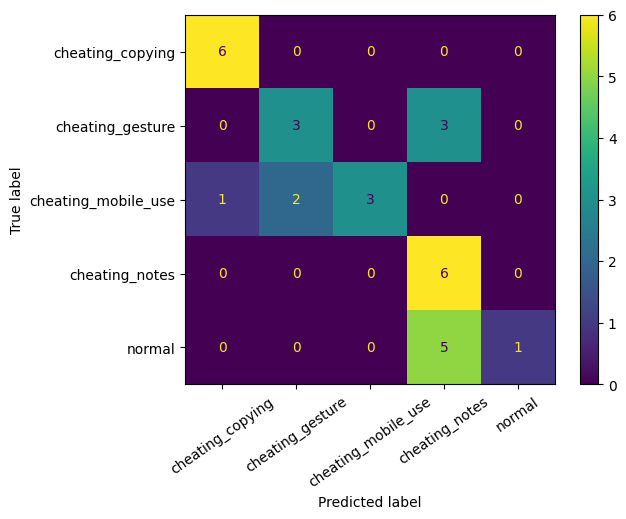

In [ ]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

disp.plot(xticks_rotation=35)
print("Validation Accuracy:", acc)
plt.show()

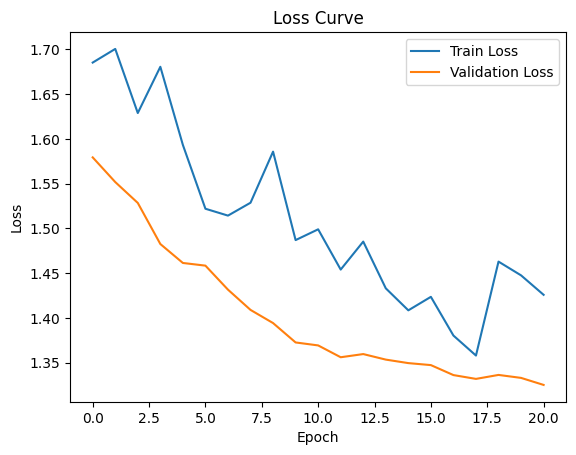

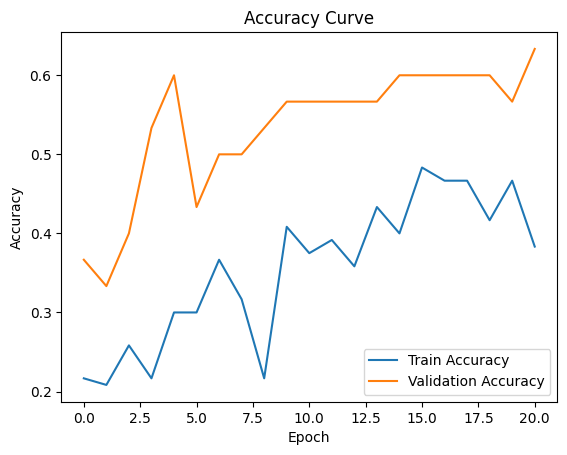

In [ ]:
# -----------------------------
# LOSS CURVE
# -----------------------------
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("/kaggle/working/loss_curve.png")
plt.show()

# -----------------------------
# ACCURACY CURVE
# -----------------------------
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("/kaggle/working/accuracy_curve.png")
plt.show()